In [1]:
import pandas as pd
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt 
import yaml
import os
import sys

plt.style.use("~/evanstyle.mplstyle") #replace with your own or comment

sys.path.append("../")
import CryoAsicAnalysis
import Utilities as Util


In [2]:
#redfile_sig = "/Volumes/CodeDrive/Gamma_Data_7_16_24/reduced/temp/combined.p"
#redfile_bk = "/Volumes/CodeDrive/Gamma_Data_7_16_24/reduced/6g24pt_bkg/combined.p"
#or on llnl
redfile_sig = "/p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/reduced/6g24pt_sig/combined.p"
redfile_bk = "/p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/reduced/6g24pt_bkg/combined.p"

df_sig = pickle.load(open(redfile_sig, "rb"))[0]
df_bk = pickle.load(open(redfile_bk, "rb"))[0]


loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file353.p
Done loading
Number of clusters in event:  2
Number of pulses in cluster:  2
Cluster times: [1629.3472222222222, 1630.6240875912408]
Pulse integrals: [12628.769796921899, 6255.918371623349]
Pulse amplitudes: [array(1447.04653923), array(1447.04653923)]


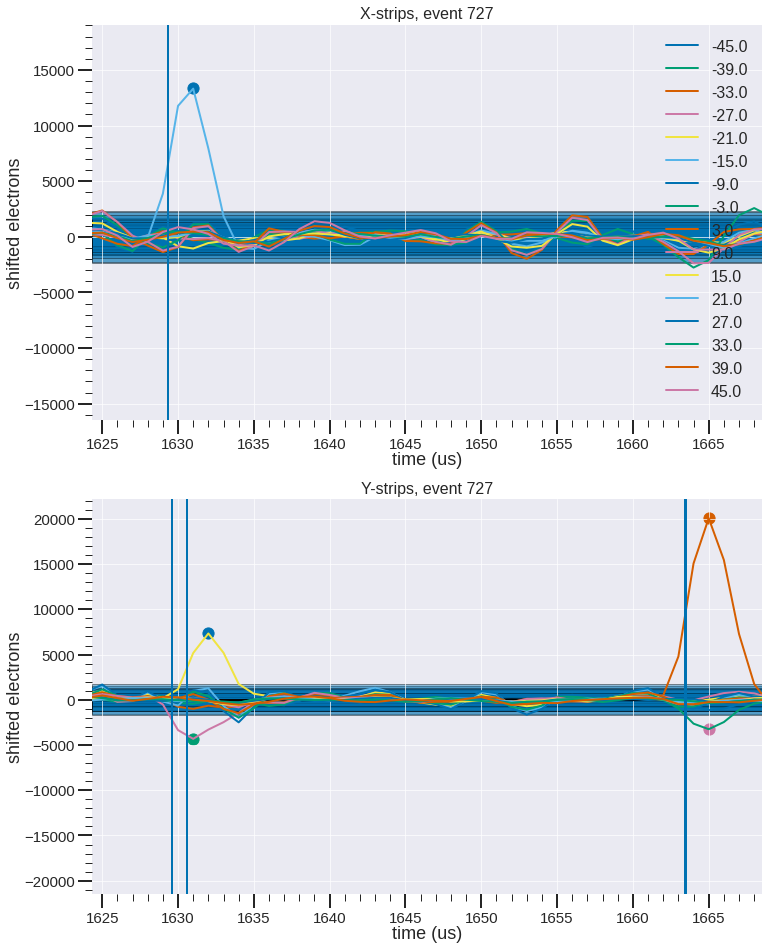

Number of pulses in cluster:  1
Cluster times: [1663.375]
Pulse integrals: [-409.2656878632097]
Pulse amplitudes: [array(-3215.65897607)]


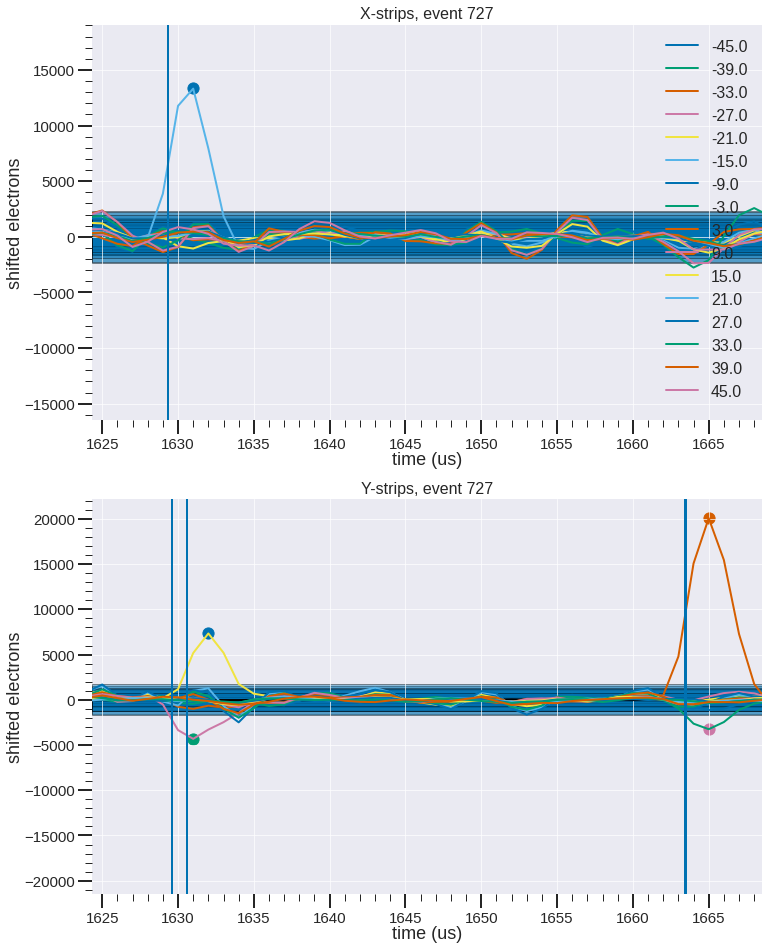

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file949.p
Done loading
Number of clusters in event:  1
Number of pulses in cluster:  2
Cluster times: [1266.954861111111, 1264.5]
Pulse integrals: [-3391.05855658088, -233.86610735040554]
Pulse amplitudes: [array(-3215.65897607), array(-3215.65897607)]


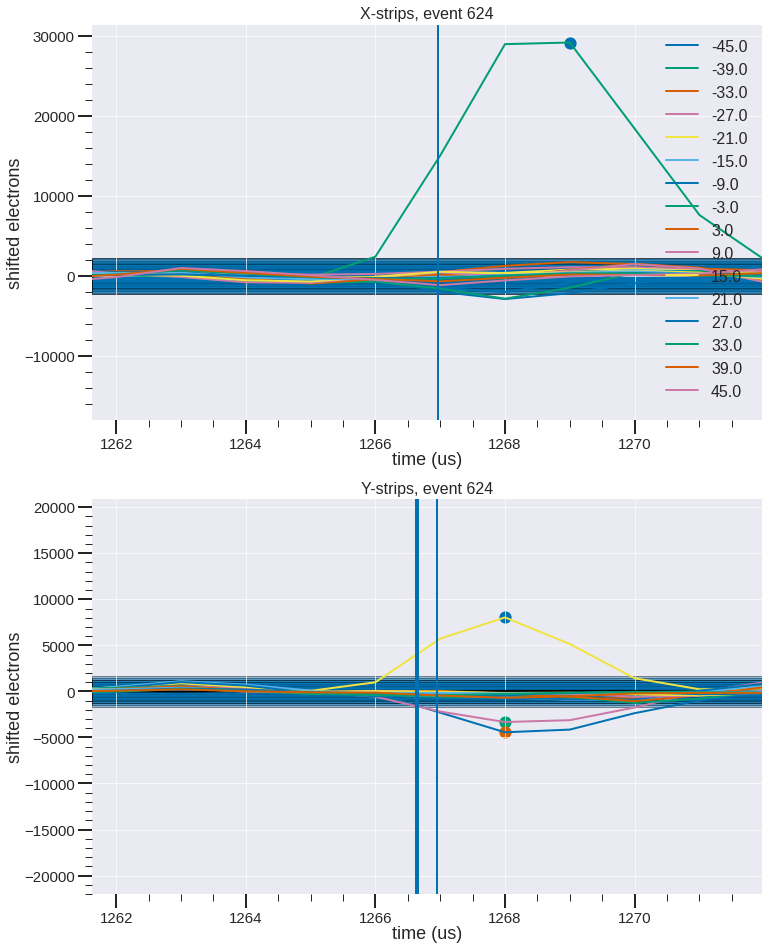

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file685.p
Done loading
Number of clusters in event:  1
Number of pulses in cluster:  1
Cluster times: [643.0480769230769]
Pulse integrals: [1067.0141147862253]
Pulse amplitudes: [array(-4458.07267137)]


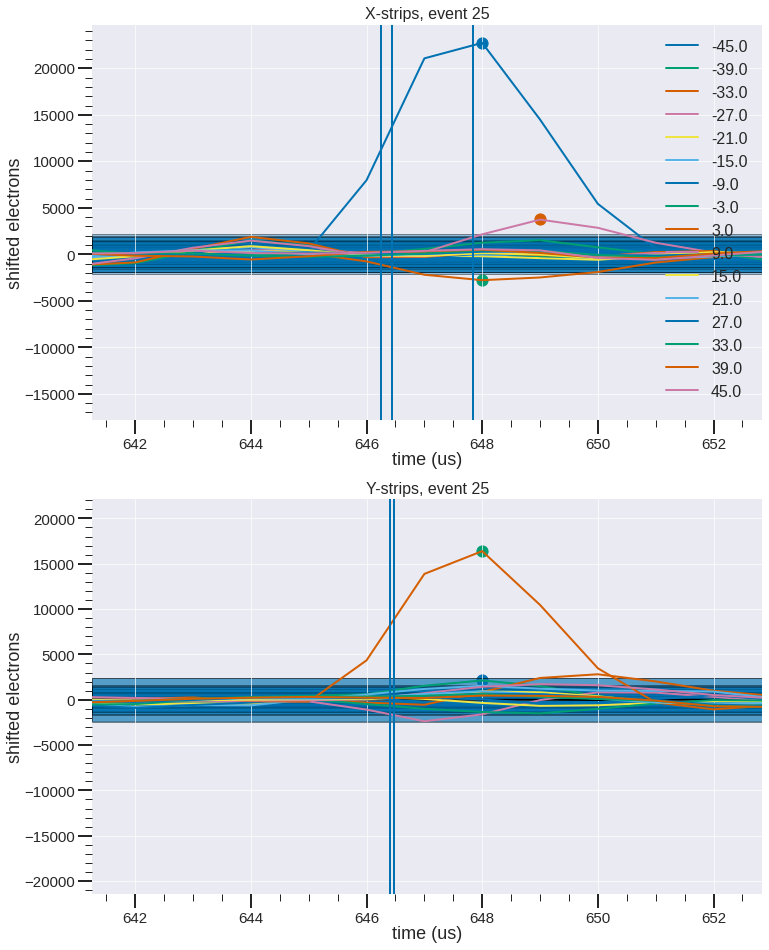

In [20]:

#change to your path
config_path = "/g/g15/angelico/cryo-asic-analysis/config/gamma-post-surg-24.yml"
#config_path = "../config/gamma-post-surg-24.yml"

df = df_sig

#a cut that I want to look at
mask = (df["total_charge"] > 10250) & (df["total_charge"] < 10500) 

#plot N random events from the events that pass this cut
n = 4
df_idxs = np.random.choice(df[mask].index, n)
df_idxs = np.unique(df_idxs)
for idx in df_idxs:
    ev = df[mask].loc[idx]
    filename = ev["filename"]
    evidx = ev["evidx"]
    clusters = ev["clusters"]


    #check if this file is accessible 
    if not os.path.exists(filename):
        print("File not found: ", filename)
        continue


    #load the file
    ca = CryoAsicAnalysis.CryoAsicAnalysis(filename, config_path)
    ca.baseline_subtract()
    print("Number of clusters in event: ", len(clusters))
    for clust in clusters:
        print("Number of pulses in cluster: ", len(clust["charge_pulses"]))
        print("Cluster times: ", end='')
        print([p["t_arrival"] for p in clust["charge_pulses"]])
        print("Pulse integrals: ", end='')
        print([p["integral"] for p in clust["charge_pulses"]])
        print("Pulse amplitudes: ", end='')
        print([p["amp"] for P in clust["charge_pulses"]])
        fig, ax = ca.plot_strips_waveforms_separated(evidx, sep=0, show=False)
        pulses = ev["pulses"]
        ts = []
        for p in pulses:
            if(Util.get_channel_type(ca.chmap, p["channel"]) == "x"):
                axidx = 0
            else:
                axidx = 1
            
            ax[axidx].scatter(p["tamp"], p["amp"], s=500)
            ax[axidx].axvline(p["t_arrival"])
            ts.append(p["t_arrival"])
            #print(p["channel"])

        for ch in range(64):
            axidx = None
            if(Util.get_channel_type(ca.chmap, ch) == "x"):
                axidx = 0
            else:
                axidx = 1
            if(axidx is None):
                continue

            std = ev["ch{:d} baseline_std".format(ch)]

            ax[axidx].axhspan(-std*3, std*3, alpha=0.4)


        ax[0].legend()
        ax[0].set_xlim([min(ts) - 5, max(ts) + 5])
        ax[1].set_xlim([min(ts) - 5, max(ts) + 5])
        #ax[0].set_ylim([-10000, 10000])
        #ax[1].set_ylim([-10000, 10000])
        plt.show()




loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_bkg/Source_Retracted_Background_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file133.p
Done loading
Number of clusters in event:  1
Number of pulses in cluster:  2
Cluster times: [1325.2222222222222, 1325.7142857142858]
loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_bkg/Source_Retracted_Background_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file80.p
Done loading
Number of clusters in event:  1
Number of pulses in cluster:  1
Cluster times: [1192.5208333333333]


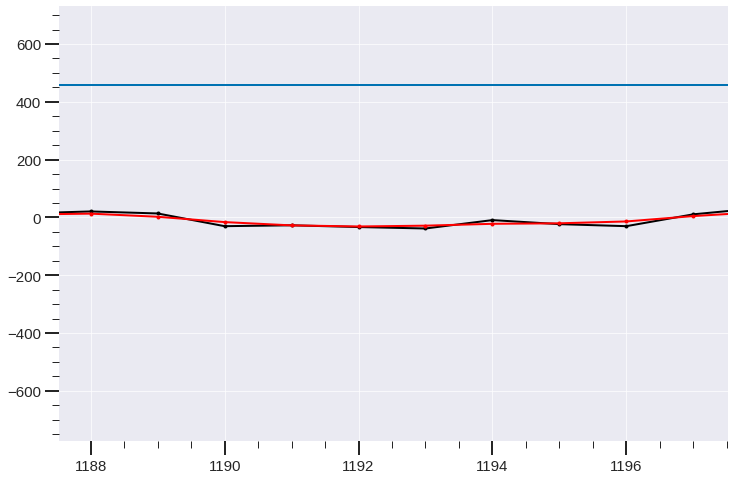

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_bkg/Source_Retracted_Background_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file364.p
Done loading
Number of clusters in event:  1
Number of pulses in cluster:  1
Cluster times: [1171.7307692307693]


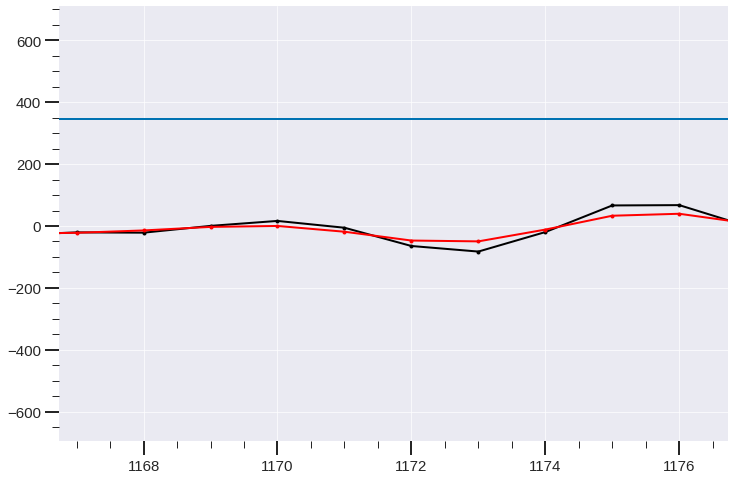

In [14]:
from scipy.ndimage import gaussian_filter
#change to your path
config_path = "/g/g15/angelico/cryo-asic-analysis/config/gamma-post-surg-24.yml"
#config_path = "../config/gamma-post-surg-24.yml"


#a cut that I want to look at
mask = (df_bk["total_charge"] > 10250) & (df_bk["total_charge"] < 10500) 

#plot N random events from the events that pass this cut
n = 3
df_idxs = np.random.choice(df_bk[mask].index, n)
df_idxs = np.unique(df_idxs)
for idx in df_idxs:
    ev = df_bk[mask].loc[idx]
    filename = ev["filename"]
    evidx = ev["evidx"]
    clusters = ev["clusters"]


    #check if this file is accessible 
    if not os.path.exists(filename):
        print("File not found: ", filename)
        continue


    #load the file
    ca = CryoAsicAnalysis.CryoAsicAnalysis(filename, config_path)
    ca.baseline_subtract()
    chidx_map = np.array(ca.df["Channels"].to_list())[0]
    print("Number of clusters in event: ", len(clusters))
    for clust in clusters:
        print("Number of pulses in cluster: ", len(clust["charge_pulses"]))
        print("Cluster times: ", end='')
        print([p["t_arrival"] for p in clust["charge_pulses"]])
        pulses = clust["charge_pulses"]
        for p in pulses:
            if(p["channel"] != 46): continue
            fig, ax = plt.subplots()
            chidx = np.where(chidx_map == ch)[0][0]
            wav = ca.get_wave(evidx, chidx)
            ax.plot(ca.times, wav, 'ko-')
            filt = gaussian_filter(wav, 1)
            ax.plot(ca.times, filt, 'ro-')
            ax.axhline(ev["ch46 baseline_std"])

    
            ax.set_xlim([p["t_arrival"] - 5, p["t_arrival"] + 5])
        plt.show()


